# Banking Assignment — Exception Handling (100 Questions with Hints)

An unsolved assessment notebook using accounts, deposits, withdrawals, transfers, cards, loans, KYC, fraud monitoring, reconciliation, and audit trails.

**Structure:** 30 easy + 40 medium + 30 difficult = **100 questions**.


## Student instructions

Solve all questions using banking scenarios. Practice try/except, custom exceptions, chaining, cleanup, resilient batch processing. Do not store real customer data, credentials, PINs, or complete card numbers. Each question includes a graduated hint but intentionally has no solution.

**Recommended workflow:** write assumptions, implement the smallest correct function/class, test normal and edge cases, then explain your design.


---

## Easy

Fundamentals and direct applications.


### Q1. Parse a deposit amount for banking case 1; use sample reference `ACC-1001` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
def parse_deposit_amount(raw_amount):
    try:
        amount = float(raw_amount)
    except (ValueError, TypeError):
        print(f"Invalid amount: {raw_amount}")
        return None
    if amount <= 0:
        print("Amount must be positive")
        return None
    return amount

print(parse_deposit_amount("250.50"))
print(parse_deposit_amount("abc"))
print(parse_deposit_amount(None))
print(parse_deposit_amount("-100"))
# TypeError: the input is the wrong kind of thing — a fundamentally incompatible type for the operation.
# ValueError: the input is the right kind of thing (right type), but its value doesn't make sense for the operation.
# Notice the difference: int(12.5) (an actual float value) works and truncates to 12. But int("12.5") (a string) fails, because int()'s string parser has no concept of "decimal point" — it's strictly integer-text-only

250.5
Invalid amount: abc
None
Invalid amount: None
None
Amount must be positive
None


### Q2. Handle a missing account key for banking case 1; use sample reference `ACC-1002` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [2]:
accounts = {"ACC-1002": 1500, "ACC-2002": 300}

def get_balance(account_ref):
    try:
        return accounts[account_ref]
    except KeyError:
        print(f"Account {account_ref} not found")
        return None

print(get_balance("ACC-1002"))
print(get_balance("ACC-9999"))


1500
Account ACC-9999 not found
None


### Q3. Prevent division by zero in average balance for banking case 1; use sample reference `ACC-1003` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [8]:
def average_balance(balance_history):
    try:
        return sum(balance_history) / len(balance_history)
    except ZeroDivisionError as e:
        print(e)
        print("No balance history available ,")
        return 0

print(average_balance([1000, 1200, 800]))
print(average_balance([]))

1000.0
division by zero
No balance history available ,
0


### Q4. Open a transaction file safely for banking case 1; use sample reference `ACC-1004` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

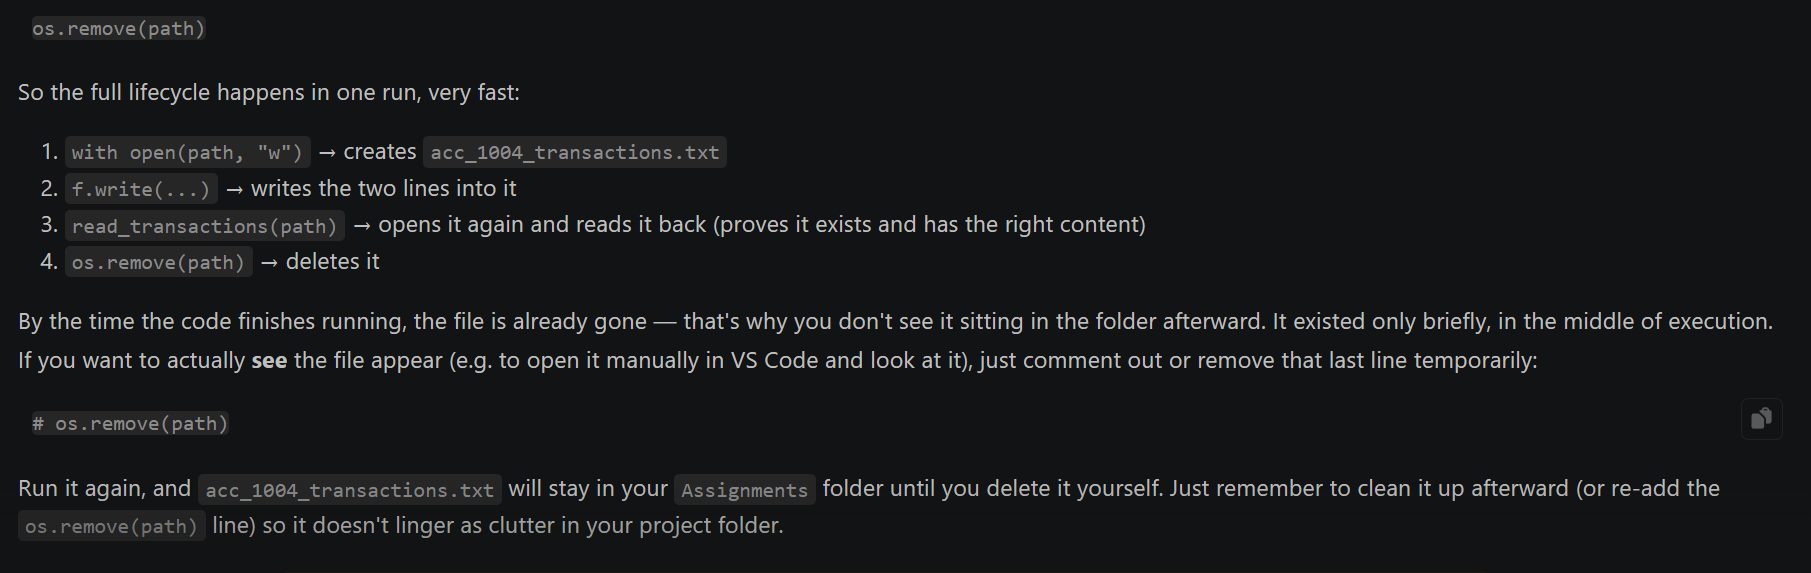

In [16]:
import os

path = "acc_1004_transactions.txt"
with open(path, "w") as f:
    f.write("DEPOSIT,500\nWITHDRAW,100\n")

def read_transactions(path):
    try:
        with open(path, "r") as f:
            return f.read()
    except FileNotFoundError:
        print(f"File not found: {path}")
        return None

print(read_transactions(path))
print(read_transactions("missing.txt"))

os.remove(path)
# Yes — a bare except: (with nothing after it) catches literally anything that goes wrong inside the try block, regardless of what kind of error it is. Python won't ever crash out of that block uncaught.

DEPOSIT,500
WITHDRAW,100

File not found: missing.txt
None


### Q5. Reject a negative withdrawal for banking case 1; use sample reference `ACC-1005` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [20]:
def withdraw(balance, amount):
    if amount < 0:
        raise ValueError("Withdrawal amount cannot be negative")
    if amount > balance:
        raise Exception("Insufficient balance - use Exception key word")
    return balance - amount

print(withdraw(1000, 200))

try:
    withdraw(1000, -50)
except ValueError as e:
    print(e)

try:
    withdraw(1000, 5000)
except Exception as e:
    print(e)

800
Withdrawal amount cannot be negative
Insufficient balance - use Exception key word


### Q6. Catch invalid tenure input for banking case 1; use sample reference `ACC-1006` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [25]:
def parse_loan_tenure(raw_tenure):
    try:
        tenure = int(raw_tenure)
    except (Exception) as e:
        print(f"{type(e).__name__}: {e}")
        return None
    return tenure

print(parse_loan_tenure("36"))
print(parse_loan_tenure("abc"))
print(parse_loan_tenure(None))


36
ValueError: invalid literal for int() with base 10: 'abc'
None
TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
None


### Q7. Use else after pin-format validation for banking case 1; use sample reference `ACC-1007` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [28]:
def validate_pin(raw_pin):
    try:
        pin = int(raw_pin)
        print(f"if this line runs without error then the else block will run -{pin}")
    except (ValueError, TypeError):
        print("Error : PIN must be numeric")
    else:
        print(f"PIN {pin} accepted")

validate_pin("4821")
validate_pin("12a4")


if this line runs without error then the else block will run -4821
PIN 4821 accepted
Error : PIN must be numeric


### Q8. Use finally to close a session for banking case 1; use sample reference `ACC-1008` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [30]:
def perform_operation(amount):
    print("Session opened")
    try:
        if amount <= 0:
            raise ValueError("after session close , it prints (Amount must be positive)")
        print(f"Processed amount {amount}")
    finally:
        print("Session closed",f"In try and exception handling the finally key word will always runs if there is a error or no error also")

perform_operation(100)

try:
    perform_operation(-5)
except ValueError as e:
    print(e)


Session opened
Processed amount 100
Session closed In try and exception handling the finally key word will always runs if there is a error or no error also
Session opened
Session closed In try and exception handling the finally key word will always runs if there is a error or no error also
after session close , it prints (Amount must be positive)


### Q9. Catch multiple numeric conversion errors for banking case 1; use sample reference `ACC-1009` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [31]:
def to_amount(raw_value):
    try:
        return float(raw_value)
    except (ValueError, TypeError):
        print(f"Cannot convert to amount: {raw_value}")
        return None

print(to_amount("100.5"))
print(to_amount("abc"))
print(to_amount(None))


100.5
Cannot convert to amount: abc
None
Cannot convert to amount: None
None


### Q10. Raise a clear valueerror for banking case 1; use sample reference `ACC-1010` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [39]:
def validate_account_ref(account_ref):
    if not isinstance(account_ref, str) or not account_ref.startswith("ACC-"):
        raise ValueError(f"Invalid account reference: {account_ref}")
    return account_ref

print(validate_account_ref("ACC-1010"))

for bad in ["1010", None , 1010 ,"ACC-1020", "ABC-1050"]:
    try:
        print(validate_account_ref(bad))
    except ValueError as e:
        print(e)


ACC-1010
Invalid account reference: 1010
Invalid account reference: None
Invalid account reference: 1010
ACC-1020
Invalid account reference: ABC-1050


### Q11. Parse a deposit amount for banking case 2; use sample reference `ACC-1011` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q12. Handle a missing account key for banking case 2; use sample reference `ACC-1012` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q13. Prevent division by zero in average balance for banking case 2; use sample reference `ACC-1013` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q14. Open a transaction file safely for banking case 2; use sample reference `ACC-1014` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q15. Reject a negative withdrawal for banking case 2; use sample reference `ACC-1015` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q16. Catch invalid tenure input for banking case 2; use sample reference `ACC-1016` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q17. Use else after pin-format validation for banking case 2; use sample reference `ACC-1017` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q18. Use finally to close a session for banking case 2; use sample reference `ACC-1018` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q19. Catch multiple numeric conversion errors for banking case 2; use sample reference `ACC-1019` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q20. Raise a clear valueerror for banking case 2; use sample reference `ACC-1020` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q21. Parse a deposit amount for banking case 3; use sample reference `ACC-1021` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q22. Handle a missing account key for banking case 3; use sample reference `ACC-1022` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q23. Prevent division by zero in average balance for banking case 3; use sample reference `ACC-1023` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q24. Open a transaction file safely for banking case 3; use sample reference `ACC-1024` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q25. Reject a negative withdrawal for banking case 3; use sample reference `ACC-1025` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q26. Catch invalid tenure input for banking case 3; use sample reference `ACC-1026` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q27. Use else after pin-format validation for banking case 3; use sample reference `ACC-1027` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q28. Use finally to close a session for banking case 3; use sample reference `ACC-1028` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q29. Catch multiple numeric conversion errors for banking case 3; use sample reference `ACC-1029` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q30. Raise a clear valueerror for banking case 3; use sample reference `ACC-1030` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here



---

## Medium

Reusable components and multi-step workflows.


### Q31. Create insufficientfundserror for banking case 1; use sample reference `ACC-1031` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [1]:
class InsufficientFundsError(Exception):
    pass

def withdraw(account_ref, balance, amount):
    if amount > balance:
        raise InsufficientFundsError(f"{account_ref}: cannot withdraw {amount}, balance is {balance}")
    return balance - amount

print(withdraw("ACC-1031", 1000, 400))

try:
    withdraw("ACC-1031", 1000, 5000)
except InsufficientFundsError as e:
    print(e)


600
ACC-1031: cannot withdraw 5000, balance is 1000


### Q32. Chain invalidtransactionerror from valueerror for banking case 1; use sample reference `ACC-1032` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [10]:
class InvalidTransactionError(Exception):
    pass

def process_transaction(account_ref, raw_amount):
    try:
        amount = float(raw_amount)
        if amount <= 0:
            raise ValueError("amount must be positive")
    except ValueError as exc:
        raise InvalidTransactionError(
            f"Transaction rejected for {account_ref}: {amount}") from exc
        # Raise my new InvalidTransactionError, but remember that the original ValueError caused it.
    return amount

print(process_transaction("ACC-1032", "250"))

try:
    process_transaction("ACC-1032", "-10")
except InvalidTransactionError as e:
    print(e, "| caused by:", e.__cause__)
    print(type(e).__name__, "| caused by:", type(e.__cause__).__name__)

# Create a new class called InvalidTransactionError that behaves like a normal Python exception.

250.0
Transaction rejected for ACC-1032: -10.0 | caused by: amount must be positive
InvalidTransactionError | caused by: ValueError


### Q33. Process transfers while isolating bad rows for banking case 1; use sample reference `ACC-1033` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [11]:
transfers = [
    {"ref": "ACC-1033", "to": "ACC-2001", "amount": 100},
    {"ref": "ACC-1033", "to": "ACC-2002", "amount": -50},
    {"ref": "ACC-1033", "to": None, "amount": 75},
    {"ref": "ACC-1033", "to": "ACC-2003", "amount": 200},
]

def apply_transfer(row):
    if not row.get("to"):
        raise ValueError("missing beneficiary")
    if row["amount"] <= 0:
        raise ValueError("amount must be positive")
    return {"to": row["to"], "amount": row["amount"]}

successes, failures = [], []
for row in transfers:
    try:
        successes.append(apply_transfer(row))
    except ValueError as e:
        failures.append({"row": row, "error": str(e)})

print("Succeeded:", successes)
print("Failed:", failures)


Succeeded: [{'to': 'ACC-2001', 'amount': 100}, {'to': 'ACC-2003', 'amount': 200}]
Failed: [{'row': {'ref': 'ACC-1033', 'to': 'ACC-2002', 'amount': -50}, 'error': 'amount must be positive'}, {'row': {'ref': 'ACC-1033', 'to': None, 'amount': 75}, 'error': 'missing beneficiary'}]


### Q34. Retry a transient payment gateway for banking case 1; use sample reference `ACC-1034` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [12]:
class GatewayTimeoutError(Exception):
    pass

def call_payment_gateway(account_ref, attempt_state={"count": 0}):
    attempt_state["count"] += 1
    if attempt_state["count"] < 3:
        raise GatewayTimeoutError(f"Gateway timed out for {account_ref}")
    return f"Payment for {account_ref} settled"

def retry_gateway(account_ref, max_attempts=5):
    for attempt in range(1, max_attempts + 1):
        try:
            return call_payment_gateway(account_ref)
        except GatewayTimeoutError as exc:
            print(f"attempt {attempt} failed: {exc}")
    raise ConnectionError(f"Gateway unreachable after {max_attempts} attempts")

print(retry_gateway("ACC-1034"))


attempt 1 failed: Gateway timed out for ACC-1034
attempt 2 failed: Gateway timed out for ACC-1034
Payment for ACC-1034 settled


### Q35. Log failed standing instructions for banking case 1; use sample reference `ACC-1035` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [13]:
standing_instructions = [
    {"ref": "ACC-1035", "amount": 500},
    {"ref": "ACC-1035", "amount": -20},
    {"ref": "ACC-1035", "amount": "bad"},
]

failure_log = []

def execute_instruction(instr):
    amount = instr["amount"]
    if not isinstance(amount, (int, float)):
        raise TypeError(f"amount must be numeric, got {amount!r}")
    if amount <= 0:
        raise ValueError(f"amount must be positive, got {amount}")
    return f"Paid {amount} for {instr['ref']}"

for instr in standing_instructions:
    try:
        print(execute_instruction(instr))
    except (TypeError, ValueError) as e:
        failure_log.append({"instruction": instr, "error": str(e)})
        print(f"Logged failure: {instr} -> {e}")

print("Failure log:", failure_log)


Paid 500 for ACC-1035
Logged failure: {'ref': 'ACC-1035', 'amount': -20} -> amount must be positive, got -20
Logged failure: {'ref': 'ACC-1035', 'amount': 'bad'} -> amount must be numeric, got 'bad'
Failure log: [{'instruction': {'ref': 'ACC-1035', 'amount': -20}, 'error': 'amount must be positive, got -20'}, {'instruction': {'ref': 'ACC-1035', 'amount': 'bad'}, 'error': "amount must be numeric, got 'bad'"}]


### Q36. Return a structured failure result for banking case 1; use sample reference `ACC-1036` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [14]:
def safe_deposit(account_ref, raw_amount):
    try:
        amount = float(raw_amount)
        if amount <= 0:
            raise ValueError("amount must be positive")
    except (TypeError, ValueError) as exc:
        return {"success": False, "account_ref": account_ref, "error": str(exc)}
    return {"success": True, "account_ref": account_ref, "new_amount": amount}

print(safe_deposit("ACC-1036", "300"))
print(safe_deposit("ACC-1036", "-10"))
print(safe_deposit("ACC-1036", None))


{'success': True, 'account_ref': 'ACC-1036', 'new_amount': 300.0}
{'success': False, 'account_ref': 'ACC-1036', 'error': 'amount must be positive'}
{'success': False, 'account_ref': 'ACC-1036', 'error': "float() argument must be a string or a real number, not 'NoneType'"}


### Q37. Validate a nested beneficiary record for banking case 1; use sample reference `ACC-1037` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [15]:
def validate_beneficiary(record):
    try:
        name = record["beneficiary"]["name"]
        iban = record["beneficiary"]["account"]["iban"]
    except KeyError as exc:
        raise ValueError(f"Missing beneficiary field: {exc}") from exc
    except TypeError as exc:
        raise ValueError("Beneficiary record is malformed") from exc
    if not name or not iban:
        raise ValueError("Beneficiary name/iban cannot be empty")
    return {"name": name, "iban": iban}

good = {"ref": "ACC-1037", "beneficiary": {"name": "J Doe", "account": {"iban": "GB00XYZ"}}}
print(validate_beneficiary(good))

bad_records = [
    {"ref": "ACC-1037", "beneficiary": {"name": "J Doe"}},
    {"ref": "ACC-1037"},
    {"ref": "ACC-1037", "beneficiary": None},
]
for rec in bad_records:
    try:
        validate_beneficiary(rec)
    except ValueError as e:
        print(f"{rec}: {e}")


{'name': 'J Doe', 'iban': 'GB00XYZ'}
{'ref': 'ACC-1037', 'beneficiary': {'name': 'J Doe'}}: Missing beneficiary field: 'account'
{'ref': 'ACC-1037'}: Missing beneficiary field: 'beneficiary'
{'ref': 'ACC-1037', 'beneficiary': None}: Beneficiary record is malformed


### Q38. Use a context manager for an audit file for banking case 1; use sample reference `ACC-1038` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In Python, a context manager is a built-in tool used to manage resources efficiently by automating their setup and cleanup. It is most commonly invoked using the with statement, which ensures that external resources (like files, network connections, or database sessions) are properly closed or released after use, even if the code encounters an error or crashes

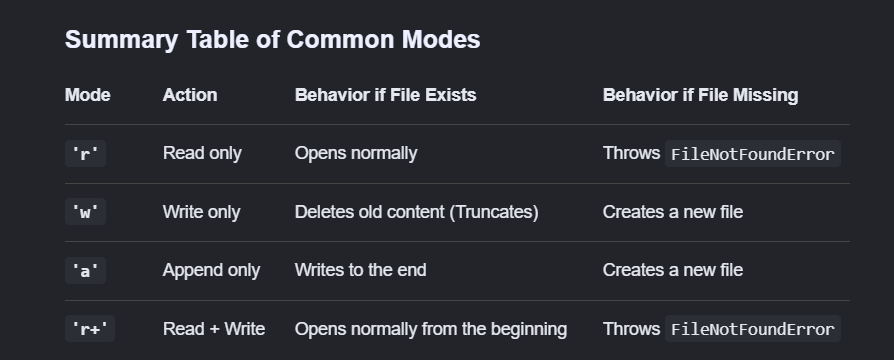

audit_log()
    │
    ├── open file
    │
    ├── try
    │
    ├── yield f
    │       │
    │       └──────────────┐
    │                      │
    ▼                      ▼
PAUSE                  with block runs
                           │
                           │
                           ▼
                       log.write(...)
                           │
                           ▼
                       RuntimeError
                           │
                           │
                           ▼
                  return to audit_log()
                           │
                           ▼
                       finally
                           │
                           ▼
                       f.close()
                       

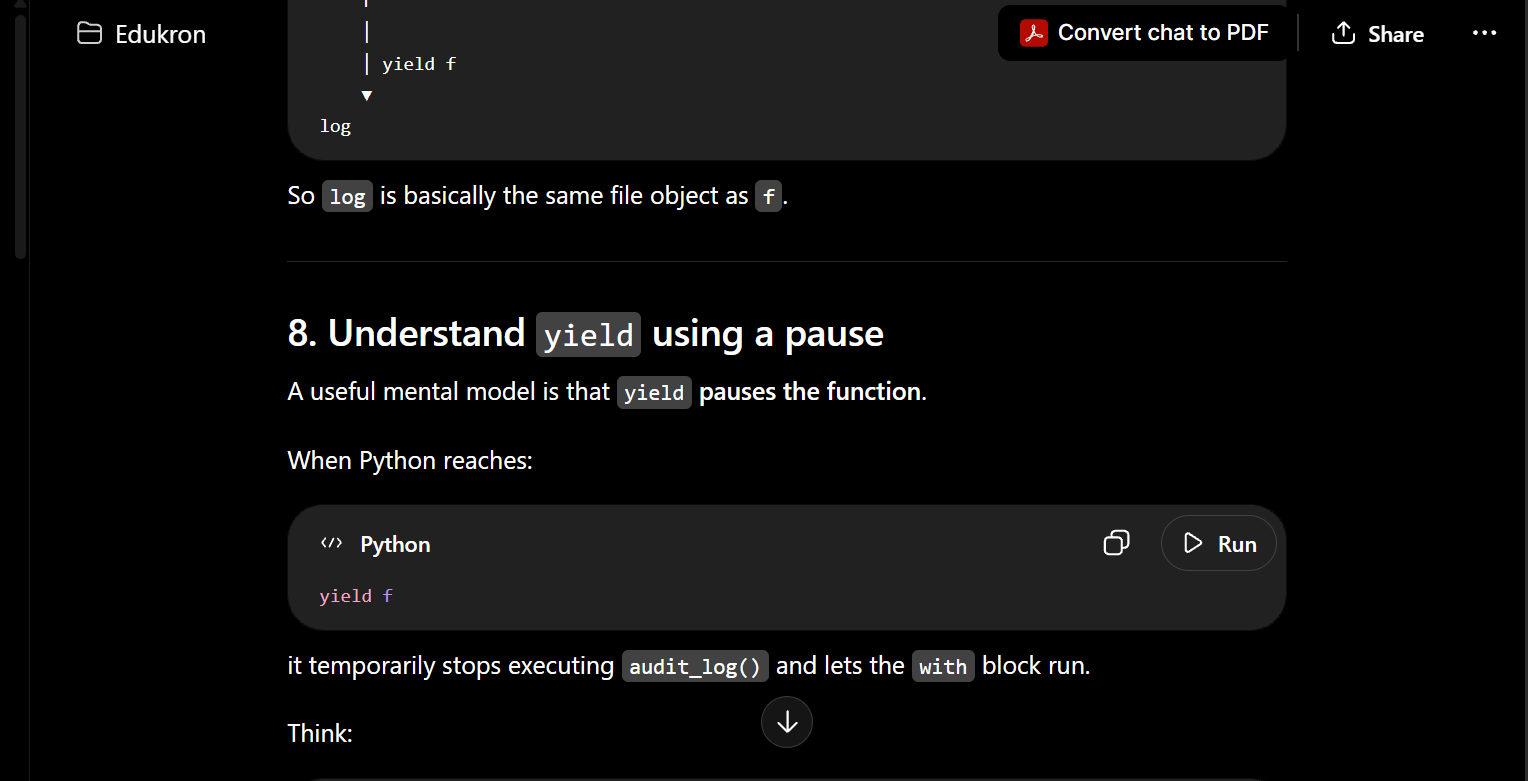

In [20]:
import os
from contextlib import contextmanager

@contextmanager
def audit_log(path):
    f = open(path, "a")
    try:
        yield f
    finally:
        f.close()

path = "acc_1038_audit.log"
try:
    with audit_log(path) as log:
        log.write("ACC-1038: withdrawal 100 OK\n")
        raise RuntimeError("downstream fraud check failed")
except RuntimeError as e:
    print("Handled:", e)

with open(path) as f:
    print("Audit file contents:", f.read())
os.remove(path)


Handled: downstream fraud check failed
Audit file contents: ACC-1038: withdrawal 100 OK



### Q39. Separate validation and recovery for banking case 1; use sample reference `ACC-1039` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [22]:
class ValidationError(Exception):
    pass

class RecoverableError(Exception):
    pass

def validate(raw_amount):
    try:
        amount = float(raw_amount)
    except (TypeError, ValueError) as exc:
        raise ValidationError(f"{raw_amount!r} is not a valid amount") from exc
    if amount <= 0:
        raise ValidationError("amount must be positive")
    return amount

def call_ledger(amount):
    if amount > 10000:
        raise RecoverableError("ledger service busy, please retry")
    return f"Recorded {amount} for ACC-1039"

def process(raw_amount):
    amount = validate(raw_amount)
    try:
        return call_ledger(amount)
    except RecoverableError as e:
        print(e)
        return call_ledger(amount / 2)

print(process("500"))
try:
    process("-1")
except ValidationError as e:
    print("Validation failed (no retry):", e)
print(process("20000"))


Recorded 500.0 for ACC-1039
Validation failed (no retry): amount must be positive
ledger service busy, please retry
Recorded 10000.0 for ACC-1039


### Q40. Collect all kyc validation errors for banking case 1; use sample reference `ACC-1040` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [28]:
def validate_kyc(record):
    errors = []
    if not record.get("full_name"):
        errors.append("full_name is required")
    if not record.get("id_number"):
        errors.append("id_number is required")
    if not record.get("date_of_birth"):
        errors.append("date_of_birth is required")
    address = record.get("address")
    if not address or not address.get("country"):
        errors.append("address.country is required")
    if errors:
        raise ValueError(f"KYC failed for ACC-1040: {errors}")
    return True

try:
    #validate_kyc({"full_name": "", "address": {}})
    validate_kyc({
        "full_name": " ",
        "date_of_birth": "1990-01-01", "address": {"country": None}
    })
except ValueError as e:
    print(e)

print(validate_kyc({
    "full_name": "Jane Doe", "id_number": "X123",
    "date_of_birth": "1990-01-01", "address": {"country": "IN"}
}))

KYC failed for ACC-1040: ['id_number is required', 'address.country is required']
True


### Q41. Create insufficientfundserror for banking case 2; use sample reference `ACC-1041` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q42. Chain invalidtransactionerror from valueerror for banking case 2; use sample reference `ACC-1042` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q43. Process transfers while isolating bad rows for banking case 2; use sample reference `ACC-1043` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q44. Retry a transient payment gateway for banking case 2; use sample reference `ACC-1044` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q45. Log failed standing instructions for banking case 2; use sample reference `ACC-1045` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q46. Return a structured failure result for banking case 2; use sample reference `ACC-1046` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q47. Validate a nested beneficiary record for banking case 2; use sample reference `ACC-1047` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q48. Use a context manager for an audit file for banking case 2; use sample reference `ACC-1048` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q49. Separate validation and recovery for banking case 2; use sample reference `ACC-1049` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q50. Collect all kyc validation errors for banking case 2; use sample reference `ACC-1050` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q51. Create insufficientfundserror for banking case 3; use sample reference `ACC-1051` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q52. Chain invalidtransactionerror from valueerror for banking case 3; use sample reference `ACC-1052` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q53. Process transfers while isolating bad rows for banking case 3; use sample reference `ACC-1053` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q54. Retry a transient payment gateway for banking case 3; use sample reference `ACC-1054` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q55. Log failed standing instructions for banking case 3; use sample reference `ACC-1055` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q56. Return a structured failure result for banking case 3; use sample reference `ACC-1056` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q57. Validate a nested beneficiary record for banking case 3; use sample reference `ACC-1057` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q58. Use a context manager for an audit file for banking case 3; use sample reference `ACC-1058` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q59. Separate validation and recovery for banking case 3; use sample reference `ACC-1059` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q60. Collect all kyc validation errors for banking case 3; use sample reference `ACC-1060` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q61. Create insufficientfundserror for banking case 4; use sample reference `ACC-1061` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q62. Chain invalidtransactionerror from valueerror for banking case 4; use sample reference `ACC-1062` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q63. Process transfers while isolating bad rows for banking case 4; use sample reference `ACC-1063` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q64. Retry a transient payment gateway for banking case 4; use sample reference `ACC-1064` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q65. Log failed standing instructions for banking case 4; use sample reference `ACC-1065` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q66. Return a structured failure result for banking case 4; use sample reference `ACC-1066` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q67. Validate a nested beneficiary record for banking case 4; use sample reference `ACC-1067` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q68. Use a context manager for an audit file for banking case 4; use sample reference `ACC-1068` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q69. Separate validation and recovery for banking case 4; use sample reference `ACC-1069` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q70. Collect all kyc validation errors for banking case 4; use sample reference `ACC-1070` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here



---

## Difficult

Architecture, edge cases, and end-to-end banking systems.


### Q71. Design a banking exception hierarchy for banking case 1; use sample reference `ACC-1071` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
class BankingError(Exception):
    pass

class InvalidAccountError(BankingError):
    pass

class InsufficientFundsError(BankingError):
    pass

class FraudSuspectedError(BankingError):
    pass

def process(account_ref, balance, amount):
    if not account_ref.startswith("ACC-"):
        raise InvalidAccountError(f"Bad account ref {account_ref}")
    if amount > balance:
        raise InsufficientFundsError(f"{account_ref}: {amount} > {balance}")
    if amount > 100000:
        raise FraudSuspectedError(f"{account_ref}: unusually large amount {amount}")
    return balance - amount

for args in [("ACC-1071", 1000, 200), ("bad", 1000, 200), ("ACC-1071", 1000, 5000), ("ACC-1071", 1000, 200000)]:
    try:
        print(process(*args))
    except BankingError as e:
        print(f"{type(e).__name__}: {e}")


### Q72. Make a transfer rollback-safe for banking case 1; use sample reference `ACC-1072` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
class TransferError(Exception):
    pass

ledger = {"ACC-1072": 1000, "ACC-2072": 200}

def transfer(from_ref, to_ref, amount):
    if ledger[from_ref] < amount:
        raise TransferError("insufficient funds")
    ledger[from_ref] -= amount
    try:
        if to_ref not in ledger:
            raise TransferError(f"unknown beneficiary {to_ref}")
        ledger[to_ref] += amount
    except TransferError:
        ledger[from_ref] += amount
        raise
    return dict(ledger)

print(transfer("ACC-1072", "ACC-2072", 100))
print("Balances:", ledger)

try:
    transfer("ACC-1072", "ACC-9999", 100)
except TransferError as e:
    print(f"Transfer rolled back: {e}")
print("Balances unchanged after rollback:", ledger)


### Q73. Preserve causes across service layers for banking case 1; use sample reference `ACC-1073` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
class RepositoryError(Exception):
    pass

class ServiceError(Exception):
    pass

class ApiError(Exception):
    pass

def repository_get_balance(account_ref):
    accounts = {"ACC-1073": 500}
    try:
        return accounts[account_ref]
    except KeyError as exc:
        raise RepositoryError(f"row not found for {account_ref}") from exc

def service_get_balance(account_ref):
    try:
        return repository_get_balance(account_ref)
    except RepositoryError as exc:
        raise ServiceError(f"could not load balance for {account_ref}") from exc

def api_get_balance(account_ref):
    try:
        return service_get_balance(account_ref)
    except ServiceError as exc:
        raise ApiError(f"GET /accounts/{account_ref}/balance failed") from exc

try:
    api_get_balance("ACC-9999")
except ApiError as e:
    cause = e
    while cause is not None:
        print(type(cause).__name__, "->", cause)
        cause = cause.__cause__


### Q74. Implement bounded exponential retry for banking case 1; use sample reference `ACC-1074` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
import time

class TransientGatewayError(Exception):
    pass

def flaky_call(account_ref, state={"n": 0}):
    state["n"] += 1
    if state["n"] < 4:
        raise TransientGatewayError(f"attempt {state['n']} failed for {account_ref}")
    return f"ok on attempt {state['n']}"

def bounded_retry(func, *args, max_attempts=5, base_delay=0.01):
    for attempt in range(max_attempts):
        try:
            return func(*args)
        except TransientGatewayError as exc:
            if attempt == max_attempts - 1:
                raise ConnectionError("max retries exceeded") from exc
            delay = base_delay * (2 ** attempt)
            print(f"retrying in {delay:.3f}s after: {exc}")
            time.sleep(delay)

print(bounded_retry(flaky_call, "ACC-1074"))


### Q75. Create a transaction context manager for banking case 1; use sample reference `ACC-1075` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
from contextlib import contextmanager

ledger = {"ACC-1075": 1000}

@contextmanager
def bank_transaction(account_ref):
    snapshot = ledger[account_ref]
    try:
        yield ledger
    except Exception:
        ledger[account_ref] = snapshot
        raise
    else:
        print(f"Transaction committed for {account_ref}")

with bank_transaction("ACC-1075") as led:
    led["ACC-1075"] -= 100
print("After committed tx:", ledger)

try:
    with bank_transaction("ACC-1075") as led:
        led["ACC-1075"] -= 5000
        raise RuntimeError("downstream validation failed")
except RuntimeError as e:
    print("Handled:", e)
print("After rolled-back tx:", ledger)


### Q76. Build a dead-letter queue for payment events for banking case 1; use sample reference `ACC-1076` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
dead_letter_queue = []

def handle_payment_event(event, max_attempts=3):
    last_error = None
    for attempt in range(1, max_attempts + 1):
        try:
            if event["amount"] <= 0:
                raise ValueError(f"invalid amount {event['amount']}")
            return f"processed {event}"
        except ValueError as exc:
            last_error = exc
    dead_letter_queue.append({"event": event, "error": str(last_error), "attempts": max_attempts})
    return None

events = [
    {"ref": "ACC-1076", "amount": 100},
    {"ref": "ACC-1076", "amount": -50},
]
for e in events:
    result = handle_payment_event(e)
    print(result if result else f"sent to DLQ: {e}")

print("Dead letter queue:", dead_letter_queue)


### Q77. Make batch settlement failure-isolated for banking case 1; use sample reference `ACC-1077` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
settlements = [
    {"ref": "ACC-1077", "amount": 100},
    {"ref": "ACC-1077", "amount": -10},
    {"ref": "ACC-1077", "amount": "x"},
    {"ref": "ACC-1077", "amount": 250},
]

def settle(row):
    amount = row["amount"]
    if not isinstance(amount, (int, float)):
        raise TypeError(f"amount must be numeric, got {amount!r}")
    if amount <= 0:
        raise ValueError(f"amount must be positive, got {amount}")
    return amount

def run_batch(rows):
    report = {"settled": [], "failed": []}
    for row in rows:
        try:
            report["settled"].append(settle(row))
        except (TypeError, ValueError) as exc:
            report["failed"].append({"row": row, "error": str(exc)})
    return report

print(run_batch(settlements))


### Q78. Report exact paths in nested statements for banking case 1; use sample reference `ACC-1078` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
import sys
import traceback

def parse_amount(raw):
    return float(raw)

def validate_amount(raw):
    amount = parse_amount(raw)
    if amount <= 0:
        raise ValueError("amount must be positive")
    return amount

def process_row(row):
    try:
        try:
            return validate_amount(row["amount"])
        except ValueError as exc:
            raise ValueError(f"row rejected for {row.get('ref')}") from exc
    except ValueError:
        tb = traceback.extract_tb(sys.exc_info()[2])
        path = " -> ".join(f"{frame.name}:{frame.lineno}" for frame in tb)
        print(f"Failure path: {path}")
        raise

try:
    process_row({"ref": "ACC-1078", "amount": "-5"})
except ValueError as e:
    print("Final error:", e)


### Q79. Design idempotent recovery after timeout for banking case 1; use sample reference `ACC-1079` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
processed_requests = {}

class GatewayTimeout(Exception):
    pass

def call_gateway(idempotency_key, amount, fail_once={"done": False}):
    if not fail_once["done"]:
        fail_once["done"] = True
        raise GatewayTimeout("no response before deadline")
    return f"charged {amount}"

def charge_with_idempotency(idempotency_key, amount):
    if idempotency_key in processed_requests:
        return processed_requests[idempotency_key]
    try:
        result = call_gateway(idempotency_key, amount)
    except GatewayTimeout:
        result = call_gateway(idempotency_key, amount)
    processed_requests[idempotency_key] = result
    return result

print(charge_with_idempotency("ACC-1079-req-1", 250))
print(charge_with_idempotency("ACC-1079-req-1", 250))


### Q80. Build an exception-safe reconciliation pipeline for banking case 1; use sample reference `ACC-1080` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
def fetch_ledger_rows():
    return [{"ref": "ACC-1080", "amount": 100}, {"ref": "ACC-1080", "amount": "bad"}]

def fetch_bank_rows():
    return [{"ref": "ACC-1080", "amount": 100}]

def match_row(ledger_row, bank_rows):
    amount = float(ledger_row["amount"])
    match = next((b for b in bank_rows if b["ref"] == ledger_row["ref"] and b["amount"] == amount), None)
    if match is None:
        raise LookupError(f"no bank match for {ledger_row}")
    return match

def reconcile():
    report = {"matched": [], "unmatched": [], "errors": []}
    bank_rows = fetch_bank_rows()
    for row in fetch_ledger_rows():
        try:
            report["matched"].append(match_row(row, bank_rows))
        except ValueError as exc:
            report["errors"].append({"row": row, "error": f"bad data: {exc}"})
        except LookupError as exc:
            report["unmatched"].append({"row": row, "error": str(exc)})
    return report

print(reconcile())


### Q81. Design a banking exception hierarchy for banking case 2; use sample reference `ACC-1081` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q82. Make a transfer rollback-safe for banking case 2; use sample reference `ACC-1082` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q83. Preserve causes across service layers for banking case 2; use sample reference `ACC-1083` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q84. Implement bounded exponential retry for banking case 2; use sample reference `ACC-1084` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q85. Create a transaction context manager for banking case 2; use sample reference `ACC-1085` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q86. Build a dead-letter queue for payment events for banking case 2; use sample reference `ACC-1086` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q87. Make batch settlement failure-isolated for banking case 2; use sample reference `ACC-1087` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q88. Report exact paths in nested statements for banking case 2; use sample reference `ACC-1088` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q89. Design idempotent recovery after timeout for banking case 2; use sample reference `ACC-1089` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q90. Build an exception-safe reconciliation pipeline for banking case 2; use sample reference `ACC-1090` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q91. Design a banking exception hierarchy for banking case 3; use sample reference `ACC-1091` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q92. Make a transfer rollback-safe for banking case 3; use sample reference `ACC-1092` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q93. Preserve causes across service layers for banking case 3; use sample reference `ACC-1093` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q94. Implement bounded exponential retry for banking case 3; use sample reference `ACC-1094` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q95. Create a transaction context manager for banking case 3; use sample reference `ACC-1095` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q96. Build a dead-letter queue for payment events for banking case 3; use sample reference `ACC-1096` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q97. Make batch settlement failure-isolated for banking case 3; use sample reference `ACC-1097` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q98. Report exact paths in nested statements for banking case 3; use sample reference `ACC-1098` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q99. Design idempotent recovery after timeout for banking case 3; use sample reference `ACC-1099` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here


### Q100. Build an exception-safe reconciliation pipeline for banking case 3; use sample reference `ACC-1100` and explain the result.

**Hints**

1. Identify the smallest risky statement and the narrow exception it can raise.
2. Keep business-rule failures distinct from programming or infrastructure failures.
3. For medium/difficult work, preserve the original cause and protect partially updated balances.

**Edge cases to test:** empty input, invalid types, boundary values, and a realistic failure path.

In [ ]:
# Write your solution here
